# Глубинное обучение 1 / Введение в глубинное обучение, ФКН ВШЭ

## Домашнее задание 3: RNN и языковые модели

### Общая информация

Оценка после штрафа после мягкого дедлайна вычисляется по формуле $M_{\text{penalty}} = M_{\text{full}} \cdot 0.85^{t/1440}$, где $M_{\text{full}}$ — полная оценка за работу без учета штрафа, а $t$ — время в минутах, прошедшее после мягкого дедлайна (округление до двух цифр после запятой). Таким образом, спустя первые сутки после мягкого дедлайна вы не можете получить оценку выше 12.75, а если сдать через четыре дня после мягкого дедлайна, то ваш максимум — 7.83 балла.

### Оценивание и штрафы

Максимально допустимая оценка за работу — 15 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### О задании

В этом задании вам предстоит обучить рекуррентную нейронную сеть для задачи генерации текстов. В качестве данных возьмем набор из 120 тысяч анекдотов (всех категорий от А до Я включительно). Его вы можете найти в архиве `jokes.txt.zip`, который доступен по [ссылке](https://disk.yandex.com/d/fjt5xICH-ukEEA).

## Задание 1: Dataset (1 балл)

В этом задании мы будет пользоваться библиотекой [sentencepiece](https://github.com/google/sentencepiece), которая поддерживает разные форматы токенизации текстов, в том числе BPE, который мы и будем использовать. Реализуйте недостающие фрагменты кода в классе `TextDataset` в файле `dataset.py`. Датасет обучает sentencepiece токенизатор, токенизирует тексты, превращает токены в индексы и паддит до одной и той же длины (параметр `max_length`). Не забудьте, что для генерации текстов нам будут нужны специальные токены начала и конца последовательности, соответственно `BOS` и `EOS`. Существуют еще два специальных токена &mdash; паддинг `PAD` и токен `UNK`, заменяющий out-of-vocabulary токены.

In [1]:
#ячейка, чтобы на kaggle все работало
import shutil
import os

src_folder = '/kaggle/input/datasets/nikitanazarov1504/anecdots'

dst_folder = '/kaggle/working/'

files_to_copy = ['dataset.py', 'model.py', 'train.py', 'jokes.txt']

for file_name in files_to_copy:
    src_path = os.path.join(src_folder, file_name)
    dst_path = os.path.join(dst_folder, file_name)
    
    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path)
        print(f"Файл {file_name} успешно скопирован в /working/")
    else:
        print(f"ОШИБКА: Файл {file_name} не найден в {src_folder}!")

print("Сейчас в рабочей папке:", os.listdir('/kaggle/working/'))

Файл dataset.py успешно скопирован в /working/
Файл model.py успешно скопирован в /working/
Файл train.py успешно скопирован в /working/
Файл jokes.txt успешно скопирован в /working/
Сейчас в рабочей папке: ['.virtual_documents', 'model.py', 'dataset.py', 'jokes.txt', 'train.py']


In [2]:
!pip install sentencepiece

In [3]:
import torch
import numpy as np
from dataset import TextDataset

In [4]:
train_set = TextDataset(data_file='jokes.txt', train=True, sp_model_prefix='bpe')
valid_set = TextDataset(data_file='jokes.txt', train=False, sp_model_prefix='bpe')

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: jokes.txt
  input_format: 
  model_prefix: bpe
  model_type: BPE
  vocab_size: 2000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: 3
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differential_priva

In [5]:
# Код должен проходить тесты
assert len(train_set) + len(valid_set) == 120759

for _ in range(5):
    for dataset in (train_set, valid_set):
        indices, length = dataset[np.random.randint(len(dataset))]
        assert indices.shape == (dataset.max_length, )
        assert indices[0].item() == dataset.bos_id
        assert (indices == dataset.eos_id).sum().item() == 1

        eos_pos = indices.tolist().index(dataset.eos_id)
        assert torch.all(indices[eos_pos + 1:] == dataset.pad_id)
        assert (indices != dataset.pad_id).sum() == length

## Задание 2 Language model (3.5 балла)

Реализуйте класс `LanguageModel` из файла `model.py`. Мы будем генерировать текст с помощью языковой модели &mdash; это авторегрессионная вероятностная модель, которая предсказывает распределение следующего токена при условии предыдущих:

$$
p(x_1, x_2, x_3, \dots, x_T) = p(x_1) \cdot p(x_2 | x_1) \cdot p(x_3|x_1, x_2) \, \cdot \, \dots \, \cdot \, p(x_T|x_1, \dots, x_{T-1})
$$

Мы будем реализовывать ее с помощью рекуррентной нейронной сети. Ваш код должен поддерживать возможность работать как с оригинальной [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html#torch.nn.RNN), так и c [LSTM](https://bitly.com/98K8eH). На каждом временном шаге модель возвращает логиты вероятностей для следующего токена. Модель будет работать в двух режимах (не путать с `.train()` и `.eval()`):

- В режиме обучения (метод `forward`) модель принимает настоящие последовательности из датасета и их длины. На каждом временном шаге возвращаются логиты вероятностей следующего токена, что позволяет считать лосс, обучаться на трейне и валидироваться на валидации.

- В режиме генерации (инференса, метод `inference`) модель принимает некоторый префикс (возможно пустой), с которого начинать генерацию, и продолжает его. Для этого на каждом шаге генерируются новые логиты, семплируется новый токен (из распределения, заданного логитами), и процесс продолжается, пока не будет сгенерирован токен `EOS` или не будет достигнуто ограничение на длину последовательности. **Обратите внимание**, что вам не нужно прогонять всю последовательность заново через RNN после каждого нового токена, это приведет к квадратичной сложности по длине последовательности. Вам достаточно обновлять скрытое состояние, подавая на вход новый сгенерированный токен и предыдущее скрытое состояние. Кроме того, чтобы получить больше контроля над генерацией, вводится параметр температуры `temp`. Перед семплированием нужно разделить на него логиты, полученные моделью.

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [7]:
from model import LanguageModel

In [8]:
model = LanguageModel(train_set).to(device)

In [9]:
# Код должен проходить тесты
for bs in [1, 4, 16, 64, 256]:
    indices = torch.randint(high=train_set.vocab_size, size=(bs, train_set.max_length)).to(device) #добавил to(device), тк модель туда перенес
    lengths = torch.randint(low=1, high=train_set.max_length + 1, size=(bs, )).to(device) #аналогично
    logits = model(indices, lengths)
    assert logits.shape == (bs, lengths.max(), train_set.vocab_size)

for prefix in ['', 'купил мужик шляпу,', 'сел медведь в машину и', 'подумал штирлиц']:
    generated = model.inference(prefix, temp=np.random.uniform(0.1, 10))
    assert type(generated) == str
    assert generated.startswith(prefix)

## Задание 3: Training (2 балла)

Всё, что нам осталось &mdash; реализовать цикл обучения. Заполните пропуски в файле `train.py`. Не забудьте, что мы учим модель предсказывать вероятность следующего, а не текущего токена. Также рекомендуется обрезать батч индексов по самой длинной последовательности, чтобы не гонять паддинги вхолостую. Для оценки качества генерации будем использовать метрику [perplexity](https://towardsdatascience.com/perplexity-in-language-models-87a196019a94). Реализуйте ее подсчет в функции `plot_losses` (да, для этого достаточно только значения лосса).

Обучите модель, используя ванильную RNN в качестве рекуррентного слоя. Сохраните чекпойнт обученной модели, он нам еще пригодится.

In [10]:
from train import *

In [11]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(valid_set, batch_size=128, shuffle=False, num_workers=2)

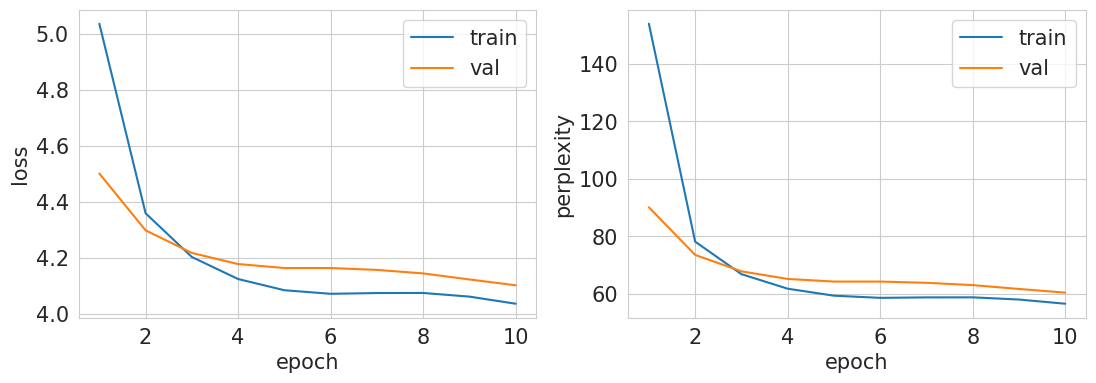

Generation examples:
дед морожен, а утром в дом добро пожалование.- не понимаю, когда видят нельзя, но проведен.- а я так понимаю, смертельно, все перепутать глупой и только гналь!
особенно начальник виды от положеннее, правительства и заметите свое взятки от добыл солдаты свиты тури.
лучший авказ, когда перестала одинакорный, игра и спрашивает- и зачем ты так так устал?- о себе! нераздновали с тобой.
нет, у меня есть пась - дайте мне постичном на сочиок.- почему я тут главная карточку в порядке лечник.- неужели?- буду будет заниматься бездовольны мальчики для себя?
не знаешь, что паросы разговаривают его расстались. шуми поизросить то, бы спасет, чтобы заорутить себя. мы еврея не вымидор!- и что же тогда переливай?- не подумала, что тогда ничего бы выезжает, чтобы мотельными. в качество понял в школах на же еду, клиенка, потому что потребовали мужчину. минекдото в коллесонцев, читающие часы сраси любом, где больше одиночеством очередном
RNN Vanilla model is saved


In [12]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
from torch import optim
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)
train(model=model, optimizer=optimizer, scheduler=scheduler, train_loader=train_loader, val_loader=val_loader, num_epochs=10)
torch.save(model.state_dict(), 'rnn_vanilla_checkpoint.pth')
print('RNN Vanilla model is saved')

## Задание 4: LSTM (0.5 балла)

Обучите аналогичную модель, но с LSTM в качестве рекуррентного слоя. Сравните модели по метрикам и генерации. Не забывайте про чекпойнты!

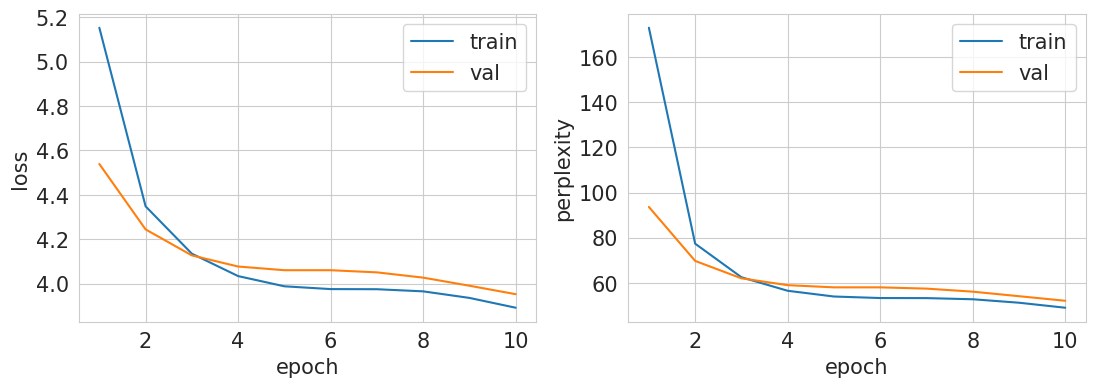

Generation examples:
идеально утро мой друг будит ван иванович, сказали, что если бы попало в отвнее он, где никто диспетчер и нептал. видишь грибы и холодная танки. идут двое глаза, чтобы не мудрые. если тот фабл и розет.
разговор под жубляеньки ковышена, но речь на  ⁇  кладбириу.на-лед, и спетна. понасюда не у мужчин соведи! и вообще! каким порвали свадером польма скватить уже большое, просто подвейца всякой мужчиков.
- как мужчина однимете спрашивать?- когда он сдал купил у меня для родителей и мотоциологи бы там... и светла эту системуров - подумал штирлиц.
дочка слава богично с определением работает о ухаживала, чтобы поставить канармой в школе. на карга пепетине к шеф.- скажите, пять человек, вы работаете предпочитать?- он так люблю.- а он?- за турчкой.- в совольный любовник.- правильно! я так поздно...
путин когда у нас была. много всякие, по борьбе. накладка поддержалась в игру, что он по ней она там, чтобы другой любимый, крованы пабавке!
LSTM model is saved


In [13]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
model_lstm = LanguageModel(train_set, rnn_type=nn.LSTM).to(device)
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=1e-3)
scheduler_lstm = optim.lr_scheduler.CosineAnnealingLR(optimizer_lstm, T_max=5)
train(model=model_lstm, optimizer=optimizer_lstm, scheduler=scheduler_lstm, train_loader=train_loader, val_loader=val_loader, num_epochs=10)
torch.save(model_lstm.state_dict(), 'lstm_checkpoint.pth')
print('LSTM model is saved')

По графикам лосса видно, что на валидации и на треине loss у LSTM меньше 4.0, а у обычной RNN больше 4.0, следовательно, LSTM справляется лучше.
По графикам перплексити тоже видно, что LSTM справляется лучше обычной RNN, так как у LSTM и на валидации, и на треине perplexity меньше 60 (около 55), а у обычной RNN только на валидации немного ниже 60 (на треине больше 60). Получается, что LSTM предсказывает следущий токен точнее.

Проверим генерацию на одном префиксе:

In [14]:
prefix = 'заходит как-то раз в бар'
print(f'Результат RNN: {model.inference(prefix)}')
print(f'Результат LSTM: {model_lstm.inference(prefix)}')

Результат RNN: заходит как-то раз в баррке в магазине спрашивает охенки полнит у мобильной работы в кладбища 20 не сможет - штирлиц и квартира!
Результат LSTM: заходит как-то раз в барцепохню, думаю и дом в метр из друзей есть в тискамов акнуцию женщины демонстраторуя рыло. его падает на улицу...


LSTM получше, так как пытается держаться на теме бара, придумывая более менее логичную историю и используя сложные слова. RNN же без механизмов памяти быстро теряет смысл и переходит к генерации случайных часто встречающихся слов (например, штирлиц)

## Задание 5: Sampling temperature (0.5 балла)

Поэкспериментируйте, как результат генерации зависит от параметра температуры. Попробуйте генерацию с разными префиксами. Сделайте выводы.

In [26]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
prefix1 = 'встретились как-то русский, американец и немец'
prefix2 = 'купил мужик шляпу,'
prefix3 = 'сел русский в мерседес и'
print(f'Анекдоты для префикса: {prefix1}')
print('Temperature = 0.2:')
print(f'- RNN: {model.inference(prefix1, temp=0.2)}')
print(f'- LSTM: {model_lstm.inference(prefix1, temp=0.2)}')
print('Temperature = 0.8:')
print(f'- RNN: {model.inference(prefix1, temp=0.8)}')
print(f'- LSTM: {model_lstm.inference(prefix1, temp=0.8)}')
print('Temperature = 1:')
print(f'- RNN: {model.inference(prefix1, temp=1)}')
print(f'- LSTM: {model_lstm.inference(prefix1, temp=1)}')
print('Temperature = 1.6:')
print(f'- RNN: {model.inference(prefix1, temp=1.6)}')
print(f'- LSTM: {model_lstm.inference(prefix1, temp=1.6)}')
print()
print(f'Анекдоты для префикса: {prefix2}')
print('Temperature = 0.2:')
print(f'- RNN: {model.inference(prefix2, temp=0.2)}')
print(f'- LSTM: {model_lstm.inference(prefix2, temp=0.2)}')
print('Temperature = 0.8:')
print(f'- RNN: {model.inference(prefix2, temp=0.8)}')
print(f'- LSTM: {model_lstm.inference(prefix2, temp=0.8)}')
print('Temperature = 1:')
print(f'- RNN: {model.inference(prefix2, temp=1)}')
print(f'- LSTM: {model_lstm.inference(prefix2, temp=1)}')
print('Temperature = 1.6:')
print(f'- RNN: {model.inference(prefix2, temp=1.6)}')
print(f'- LSTM: {model_lstm.inference(prefix2, temp=1.6)}')
print()
print(f'Анекдоты для префикса: {prefix3}')
print('Temperature = 0.2:')
print(f'- RNN: {model.inference(prefix3, temp=0.2)}')
print(f'- LSTM: {model_lstm.inference(prefix3, temp=0.2)}')
print('Temperature = 0.8:')
print(f'- RNN: {model.inference(prefix3, temp=0.8)}')
print(f'- LSTM: {model_lstm.inference(prefix3, temp=0.8)}')
print('Temperature = 1:')
print(f'- RNN: {model.inference(prefix3, temp=1)}')
print(f'- LSTM: {model_lstm.inference(prefix3, temp=1)}')
print('Temperature = 1.6:')
print(f'- RNN: {model.inference(prefix3, temp=1.6)}')
print(f'- LSTM: {model_lstm.inference(prefix3, temp=1.6)}')

Анекдоты для префикса: встретились как-то русский, американец и немец
Temperature = 0.2:
- RNN: встретились как-то русский, американец и немецкие, а потом по-русски, а не у меня.
- LSTM: встретились как-то русский, американец и немецкий.
Temperature = 0.8:
- RNN: встретились как-то русский, американец и немец на львом?- нет, как-то слон.
- LSTM: встретились как-то русский, американец и немецкий блох.
Temperature = 1:
- RNN: встретились как-то русский, американец и немецкого походешь и вы и силился, белый и твоих осталось видно, ведрома...
- LSTM: встретились как-то русский, американец и немец прямочке чая- ты сына, а кто ты попросил настоящим холодок?- ну и я возвращаюсь.
Temperature = 1.6:
- RNN: встретились как-то русский, американец и немец свой странный менуку. бы тебя раздели - большой куда играющий его со слепы, а гражданска паль американский росе же стали говорит!- а кович.- дорогая, пина выру подорович головаться звезду вокруг виз...- значит, ничего!- какой? йогательно горо вла

По температуре, при низкой (0.2) какие-то повторы и скучно, при высокой (1.6) уже начинается какой-то бред полный (много несуществующих слов), так как модель начинает выбирать токены с низкой вероятностью наравне с основными. Оптимальной является температура 0.8 и 1, и на них, по-моему, LSTM справляется лучше, чем RNN. Поэтому для след задания беру LSTM



## Задание 5: Tokenizers (1 балл)

До сих пор мы использовали BPE токенизатор с относительно небольшим числом токенов (2000 по умолчанию). Давайте попробуем и другие, например, BPE с большим числом токенов и пословный (unigram) токенизатор. Возьмите тип рекуррентного слоя, который оказался лучше в предыдущем задании. Обучите модели на таких токенизаторах и сравните их генерацию. Не забывайте сохранять чекпойнты. Правильно ли сравнивать между собой получившиеся модели по значению perplexity? Почему?

Возьму BPE с vocab_size=8000 (model_bigvocab) и unigram токенизатор (model_unigram):

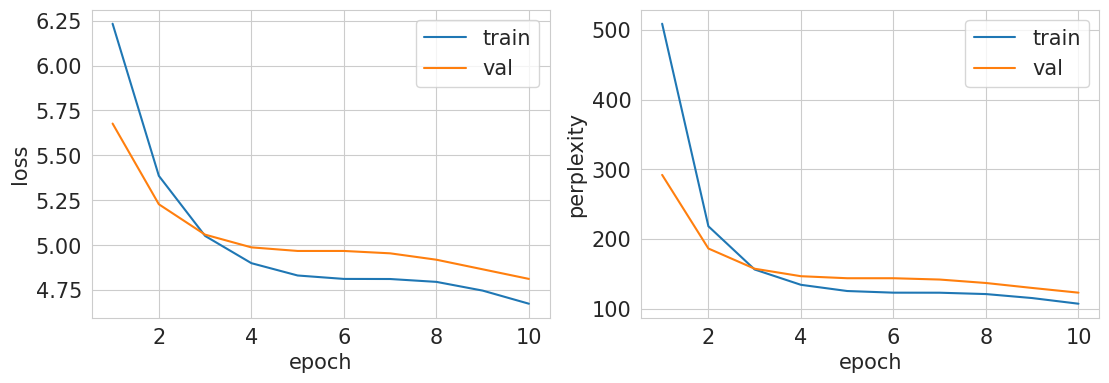

Generation examples:
- ты чего предпочитаешь еще не себя надо названием вперед? вашего нее решительно спросидно- а ты не поверишь, что там старый! а она обиделась, а какая скачетливо.- так долго ведь они нам в защиты вас сидеть заполнит.
дельтадеры лжило и заразавского летающих в куриц. преступники они на  ⁇  млты весна...
милая страшного. родители сочета...
вот, из нашего жора нолеза спокойные отношения...отвежаете про поезд из самых королей жуся юляю стрелячью знать...
- сегодня нам выговариваешь на этой колбасой губы! ручку. дверь- да.
LSTM vocab_size=8000 model is saved


In [27]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
train_set_bigvocab = TextDataset(data_file='jokes.txt', train=True, vocab_size=8000, sp_model_prefix='bpe_8000')
valid_set_bigvocab = TextDataset(data_file='jokes.txt', train=False, vocab_size=8000, sp_model_prefix='bpe_8000')
train_loader_bigvocab = DataLoader(train_set_bigvocab, batch_size=128, shuffle=True, num_workers=2)
val_loader_bigvocab = DataLoader(valid_set_bigvocab, batch_size=128, shuffle=False, num_workers=2)

model_bigvocab = LanguageModel(train_set_bigvocab, rnn_type=nn.LSTM).to(device)
optimizer_bigvocab = optim.Adam(model_bigvocab.parameters(), lr=1e-3)
scheduler_bigvocab = optim.lr_scheduler.CosineAnnealingLR(optimizer_bigvocab, T_max=5)
train(model=model_bigvocab, optimizer=optimizer_bigvocab, scheduler=scheduler_bigvocab, train_loader=train_loader_bigvocab, val_loader=val_loader_bigvocab, num_epochs=10)
torch.save(model_bigvocab.state_dict(), 'bigvocab_checkpoint.pth')
print('LSTM vocab_size=8000 model is saved')

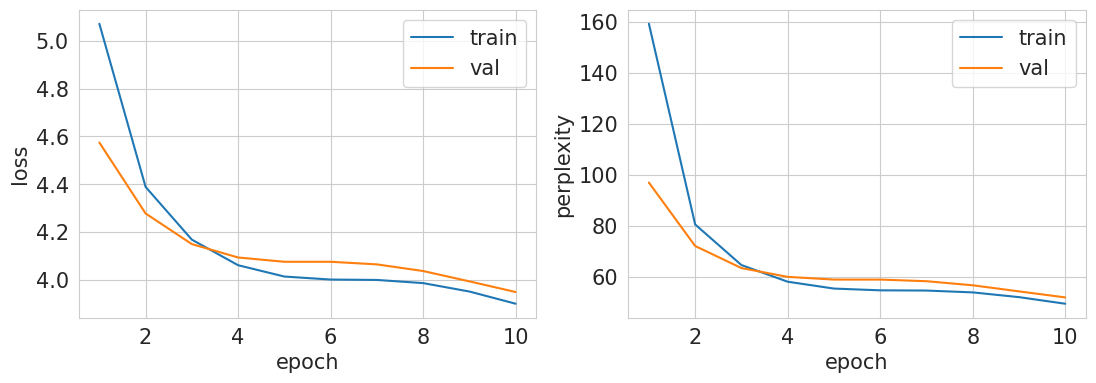

Generation examples:
петя прокурорам предастить полного оказания ходьбы кухня.
- а я начинает знаешь как я спагляю парничной новость, а все умный человек был. лентка...
связь с друзья - даже корабли порежски искорей натасбовать.
- светочка до шом баб!
ирете всех дороги... заказешь, такого. а вот с вами, как смотришь тридцатимом ктенок тем, что ничего нельзя.
LSTM unigram model is saved


In [28]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
train_set_unigram = TextDataset(data_file='jokes.txt', train=True, sp_model_prefix='unigram', model_type='unigram')
valid_set_unigram = TextDataset(data_file='jokes.txt', train=False, sp_model_prefix='unigram', model_type='unigram')
train_loader_unigram = DataLoader(train_set_unigram, batch_size=128, shuffle=True, num_workers=2)
val_loader_unigram = DataLoader(valid_set_unigram, batch_size=128, shuffle=False, num_workers=2)

model_unigram = LanguageModel(train_set_unigram, rnn_type=nn.LSTM).to(device)
optimizer_unigram = optim.Adam(model_unigram.parameters(), lr=1e-3)
scheduler_unigram = optim.lr_scheduler.CosineAnnealingLR(optimizer_unigram, T_max=5)
train(model=model_unigram, optimizer=optimizer_unigram, scheduler=scheduler_unigram, train_loader=train_loader_unigram, val_loader=val_loader_unigram, num_epochs=10)
torch.save(model_unigram.state_dict(), 'unigram_checkpoint.pth')
print('LSTM unigram model is saved')

In [33]:
prefix = 'заходит как-то раз в бар'
print(f'Результат LSTM vocab_size=8000: {model_bigvocab.inference(prefix)}')
print(f'Результат LSTM unigram: {model_unigram.inference(prefix)}')

Результат LSTM vocab_size=8000: заходит как-то раз в барлеон. хорошая. пустая.муж увидела - его под видом пятого окна.
Результат LSTM unigram: заходит как-то раз в барнулся кассир, вы чил бабушка.- у вас есть машину?- нет.- а почему?- она есть надпись надчивляется.


Благодаря большому словарю у model_bigvocab незаметно неумение склеивать слова из частей, поэтому слова получаются без опечаток. У model_unigram же присутствуют опечатки, но модель генерирует более интересный текст (даже в форме диалога), который сильнее по структуре похож на анекдот

Сравнивать получившиеся модели по perplexity нельзя, так как эта метрика считается на 1 токен, а предсказать целое слово (model_bigvocab) сложнее, чем его небольшую часть (model_unigram), поэтому у model_unigram perplexity почти в 2 раза ниже на валидации, чем у model_bigvocab, хотя текст притом необязательно качественнее. Более того, 1) model_bigvocab выбирает из 8000 токенов, а model_unigram из 2000, поэтому у первой шанс ошибиться выше; 2) одинакоые анекдоты имеют разную длину в токенах у model_bigvocab (меньше) и model_unigram (больше), поэтому средние вероятности на токен несравнимы

## Задание 6. Latent Semantic Analysis (2 балла)

Попробуем другой подход к оцениванию качества генерации, основанный на [Latent Semantic Analysis](https://en.wikipedia.org/wiki/Latent_semantic_analysis). Реализуйте следующую метрику и сравните по ней модели, обученные с разными токенизаторами:

1. Генерируем обученной моделью выборку текстов, совпадающую по размеру с валидационной выборкой.
2. Объединяем две выборки текстов (валидационную и сгенерированную) в один корпус. Обратите внимание, что наша токенизация в общем случае необратима, поэтому для чистоты эксперимента нужно закодировать и декодировать валидационную выборку.
3. Генерируем tf-idf матрицу для полученного корпуса.
4. Понижаем размерность матрицы с помощью [SVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).
5. Теперь у нас есть векторы, описывающие валидационные и сгенерированные тексты, лежащие в одном пространстве. Для каждого вектора, отвечающего сгенерированному тексту, найдем наибольший cosine similarity между ним и вектором валидационного текста. Усредним такие similarity по всем сгенерированным текстам и получим число, характеризующее похожесть сгенерированной выборки на валидационную.

Какие плюсы и минусы есть у описанной метрики?

In [46]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
import numpy as np

def lsa_score(model, valid_set):
    num_samples = len(valid_set)
    model.eval()
    generated_texts = []
    for _ in tqdm(range(num_samples)):
        t = model.inference(prefix='')
        generated_texts.append(t)
    
    raw_valid_texts = valid_set.texts
    valid_ids = valid_set.text2ids(raw_valid_texts)
    new_valid_texts = valid_set.ids2text(valid_ids)
    all_texts = new_valid_texts + generated_texts
    
    vectorizer = TfidfVectorizer()
    tf_idf_matrix = vectorizer.fit_transform(all_texts)
    
    svd = TruncatedSVD(n_components=100, random_state=42)
    dense_matrix = svd.fit_transform(tf_idf_matrix)
    valid_vectors = dense_matrix[:len(new_valid_texts)]
    generated_vectors = dense_matrix[len(new_valid_texts):]
    
    similar_matrix = cosine_similarity(generated_vectors, valid_vectors)
    max_similar = np.max(similar_matrix, axis=1)
    lsascore = np.mean(max_similar)
    
    return lsascore, valid_vectors, generated_vectors, generated_texts

In [48]:
score_lstm, valid_vectors_lstm, generated_vectors_lstm, generated_texts_lstm = lsa_score(model_lstm, valid_set)
print(f'LSA score of LSTM model: {score_lstm}')

score_bigvocab, valid_vectors_bigvocab, generated_vectors_lstm_bigvocab, generated_texts_bigvocab = lsa_score(model_bigvocab, valid_set_bigvocab)
print(f'LSA score of LSTM vocab_size=8000 model: {score_bigvocab}')

score_unigram, valid_vectors_unigram, generated_vectors_lstm_unigram, generated_texts_unigram = lsa_score(model_unigram, valid_set_unigram)
print(f'LSA score of LSTM unigram model: {score_unigram}')

  0%|          | 0/6037 [00:00<?, ?it/s]

LSA score of LSTM model: 0.7280185025982474


  0%|          | 0/6037 [00:00<?, ?it/s]

LSA score of LSTM vocab_size=8000 model: 0.7287220214652732


  0%|          | 0/6037 [00:00<?, ?it/s]

LSA score of LSTM unigram model: 0.7227727842605278


Лучше всех с большим словарем, но в целом все примерно на одном уровне - не как в perplexity, где все показывали разные (несравнимые из-за разных токенизаторов) результаты.

Плюсы LSA: 
1) Оценивает семантику (смысл), а не символы, то есть в отличие от perplexity смотрит на схожесть реальных и сгенерированных текстов
2) Возможность сравнить разные токенизаторы, так как расчет метрики идет на финальных текстах после декодирования
3) С помощью SVD в LSA учитывается контекст, поэтому он не занижает оценку, если видит слова, которые не одинаковые, но являются синонимами

Минусы LSA:
1) Не учитывает порядок слов, так как LSA важно только чтобы все слова были тематически похожи, но неважно, в каком они порядке (из-за tf-idf)
2) Завышает балл моделям, которые тупо заучили выборку и копируют ее (не учитывет оверфиттинг)
3) Игнорирует ошибки в окончаниях, так как LSA важно только, чтобы основные корни слов были распознаны как тематически верные

## Задание 7. Visualization (1 балл)

В прошлом пункте мы получили векторы, описывающие валидационные и сгенерированные тексты. Попробуем визуализировать их. Примените [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) к этим векторам и нарисуйте scatter-plot с получившимися двумерными представлениями. Точки, соответствующие валидационным и сгенерированным текстам, должны быть разного цвета. Визуализируйте таким образом все три модели для разных токенизаторов.

In [49]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def visual_lsa_tsne(valid_vectors, generated_vectors, title='LSA visualization'):
    all_vectors = np.vstack([valid_vectors, generated_vectors])
    labels = np.array([0] * len(valid_vectors) + [1] * len(generated_vectors))
    
    tsne = TSNE(random_state=42, n_jobs=-1)
    all_vectors_2d = tsne.fit_transform(all_vectors)
    
    plt.figure(figsize=(10, 7))
    plt.scatter(all_vectors_2d[labels==0, 0], all_vectors_2d[labels==0, 1], c='blue', label='validation', alpha=0.5, s=10)
    plt.scatter(all_vectors_2d[labels==1, 0], all_vectors_2d[labels==1, 1], c='yellow', label='generated', alpha=0.5, s=10)
    plt.title(title)
    plt.legend()
    plt.show()

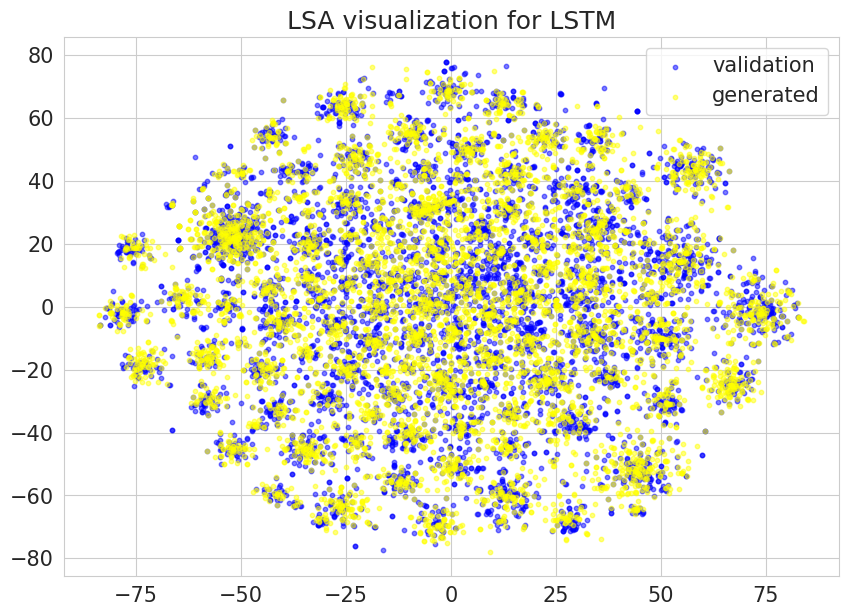

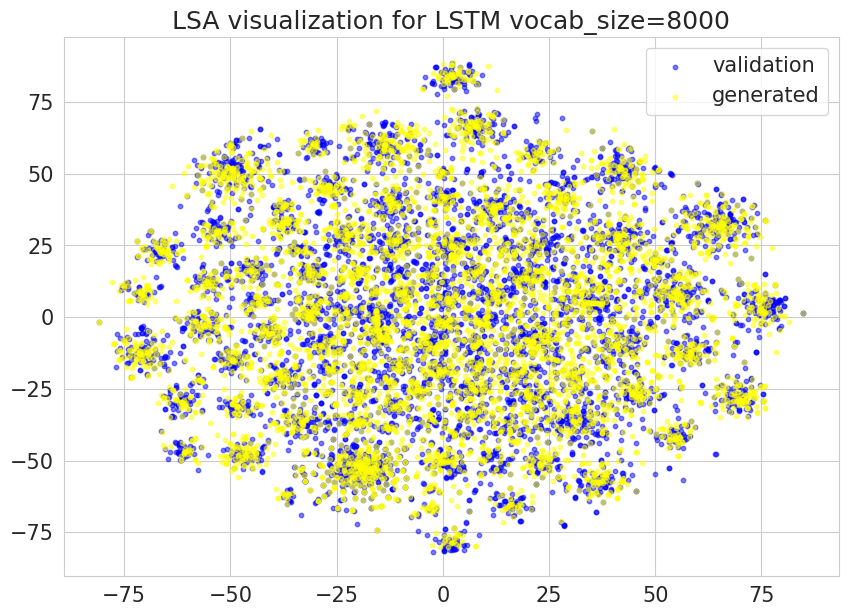

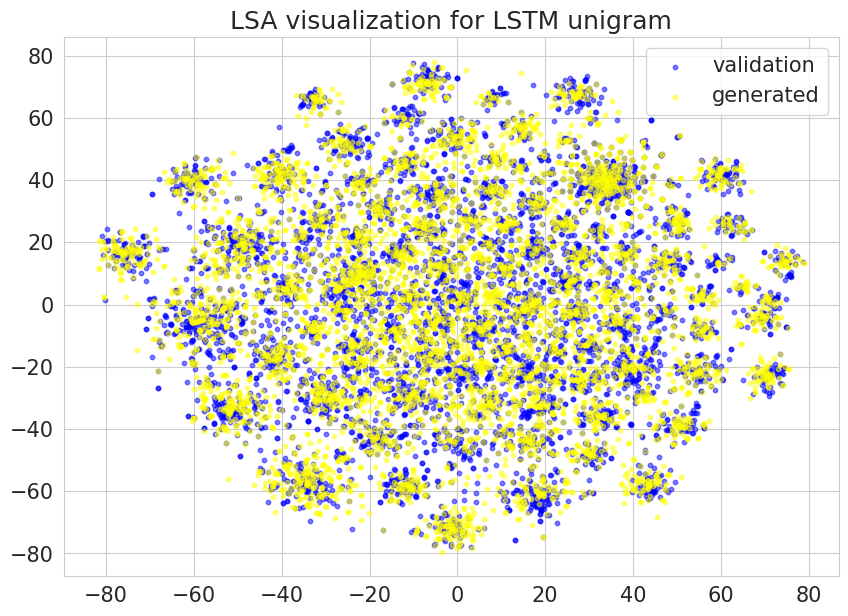

In [50]:
visual_lsa_tsne(valid_vectors_lstm, generated_vectors_lstm, title='LSA visualization for LSTM')
visual_lsa_tsne(valid_vectors_bigvocab, generated_vectors_lstm_bigvocab, title='LSA visualization for LSTM vocab_size=8000')
visual_lsa_tsne(valid_vectors_unigram, generated_vectors_lstm_unigram, title='LSA visualization for LSTM unigram')

## Задание 8. ruGPT perplexity (3.5 балла)

Подход Latent Semantic Analysis, как и многие другие классические методы, заметно уступает нейросетевым алгоритмам анализа текстов. Вернемся к оцениванию качества генерации с помощью perplexity, для этого возьмем большую и хорошо обученную языковую модель, которая училась на огромном корпусе русских текстов. Считается, что большие языковые модели хорошо выучивают естественный язык, потому с их помощью мы сможем оценивать качество наших маленьких моделей для генерации анекдотов. Для этого мы воспользуемся сервисом [HuggingFace](https://huggingface.co/), который содержит огромное число обученных моделей для самых разных задач. Изучите и реализуйте, [подсчет perplexity](https://huggingface.co/docs/transformers/perplexity), с использованием обученной языковой модели. В качестве модели возьмите [ruGPT3-small](https://huggingface.co/sberbank-ai/rugpt3small_based_on_gpt2). Сгенерируйте синтетические выборки тремя моделями, обученными выше (можете взять выборки из задания 6), и сравните их по perplexity.

In [52]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
from transformers import GPT2LMHeadModel, GPT2Tokenizer
def rugpt_perplexity(generated_texts, model_name='sberbank-ai/rugpt3small_based_on_gpt2'):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    tokenizer = GPT2Tokenizer.from_pretrained(model_name)
    model = GPT2LMHeadModel.from_pretrained(model_name).to(device)
    model.eval()
    
    total_nll = 0
    total_length = 0
    
    with torch.no_grad():
        for text in tqdm(generated_texts):
            encods = tokenizer(text, return_tensors='pt')
            input_indices = encods.input_ids.to(device)
            target_indices = input_indices.clone()
            
            outputs = model(input_indices, labels=target_indices)
            nll = outputs.loss * input_indices.shape[1]
            
            total_nll += nll.item()
            total_length += input_indices.shape[1]
    
    ppl = np.exp(total_nll / total_length)
    return ppl

In [54]:
rugpt3_ppl_lstm = rugpt_perplexity(generated_texts_lstm)
print(f'ruGPT perplexity of LSTM model: {rugpt3_ppl_lstm}')


rugpt3_ppl_bigvocab = rugpt_perplexity(generated_texts_bigvocab)
print(f'ruGPT perplexity of LSTM vocab_size=8000 model: {rugpt3_ppl_bigvocab}')


rugpt3_ppl_unigram = rugpt_perplexity(generated_texts_unigram)
print(f'ruGPT perplexity of LSTM unigram model: {rugpt3_ppl_unigram}')

  0%|          | 0/6037 [00:00<?, ?it/s]

ruGPT perplexity of LSTM model: 2300.1863995663484


  0%|          | 0/6037 [00:00<?, ?it/s]

ruGPT perplexity of LSTM vocab_size=8000 model: 1839.9753934961363


  0%|          | 0/6037 [00:00<?, ?it/s]

ruGPT perplexity of LSTM unigram model: 2348.241240150071


По ruGPT perplexity model_bigvocab обогнала всех, у нее эта метрика значительно меньше, чем у остальных. Скорее всего, это связано с тем, что большой словарь позволяет ей генерировать более цельные и грамматически верные слова, которые обученная языковая модель ruGPT3-small воспринимает как более естественные 

## Бонус (0.1 балл)

Покажите лучший анекдот, который удалось сгенерировать вашей модели. Если проверяющий найдет его смешным, то поставит 0.1 балла.

In [55]:
prefix_best = 'Приходит мужик домой, а там'
print(f'Лучший анекдот: {model_bigvocab.inference(prefix_best, temp=0.7)}')

Лучший анекдот: приходит мужик домой, а там сидит в лужу- и чего же ты говоришь?- хорошие новости.
